In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path
from IPython.display import display

plt.rcParams.update({'font.size': 12, 'axes.labelsize': 12, 'axes.titlesize': 12, 'xtick.labelsize': 12, 'ytick.labelsize': 12, 'legend.fontsize': 11, 'pdf.fonttype': 42})

In [13]:
data_dir = Path('../Data')
results_dir = Path('../Results')
figures_dir = results_dir / 'Figures'
table_dir = results_dir / 'Table'
output_data_dir = results_dir / 'Output Data'
for output_dir in [figures_dir, table_dir, output_data_dir]:
    output_dir.mkdir(parents=True, exist_ok=True)

dt = 0.25
expected_rows = 35136
granular_periods = ['M01', 'M02', 'M03', 'Q2', 'Q3', 'Q4']
month_to_period = {1: 'M01', 2: 'M02', 3: 'M03', 4: 'Q2', 5: 'Q2', 6: 'Q2', 7: 'Q3', 8: 'Q3', 9: 'Q3', 10: 'Q4', 11: 'Q4', 12: 'Q4'}

slp = pd.read_csv(data_dir / 'slp_profiles.csv')
futures = pd.read_csv(data_dir / 'futures_prices.csv')
day_ahead = pd.read_csv(data_dir / 'day_ahead_prices.csv')
actual_load = pd.read_csv(data_dir / 'actual_portfolio_load.csv')
imbalance = pd.read_csv(data_dir / 'imbalance_prices.csv')
hpfc = pd.read_csv(output_data_dir / 'GRANULAR_hpfc_curve.csv')

In [14]:
for data in [slp, day_ahead, actual_load, imbalance]:
    data['timestamp_utc'] = pd.to_datetime(data['timestamp_utc'], utc=True)

hpfc['timestamp_utc'] = pd.to_datetime(hpfc['timestamp_local'], utc=True)
hpfc = hpfc[['timestamp_utc', 'hpfc_eur_mwh']]

time_series = {'SLP': slp, 'HPFC': hpfc, 'Day-Ahead': day_ahead, 'Actual Load': actual_load, 'reBAP': imbalance}
input_checks = pd.DataFrame([{'Input': name, 'Rows': len(data), 'Unique UTC': data['timestamp_utc'].nunique(), 'Missing': data.isna().sum().sum()} for name, data in time_series.items()])
assert input_checks['Rows'].eq(expected_rows).all()
assert input_checks['Unique UTC'].eq(expected_rows).all()
assert input_checks['Missing'].eq(0).all()
assert all(data['timestamp_utc'].equals(slp['timestamp_utc']) for data in [hpfc, day_ahead, actual_load, imbalance])
display(input_checks)

,Input,Rows,Unique UTC,Missing
0,SLP,35136,35136,0
1,HPFC,35136,35136,0
2,Day-Ahead,35136,35136,0
3,Actual Load,35136,35136,0
4,reBAP,35136,35136,0


## Inputs

The 2023-09-29 futures snapshot and the contract-consistent granular HPFC determine the hedge. Realised 2024 Day-Ahead prices, actual load, and reBAP are used only for the backtest.

In [15]:
annual_energy_mwh = {'HB': 35000.0, 'GB': 6000.0, 'LB': 2000.0}
profile_columns = {'HB': 'hb_normalized_kwh', 'GB': 'gb_normalized_kwh', 'LB': 'lb_normalized_kwh'}

forecast = slp[['timestamp_utc']].copy()
forecast['timestamp_local'] = forecast['timestamp_utc'].dt.tz_convert('Europe/Berlin')
for profile, column in profile_columns.items():
    forecast[f'{profile.lower()}_mwh'] = slp[column] * annual_energy_mwh[profile] / slp[column].sum()
forecast['forecast_mwh'] = forecast[['hb_mwh', 'gb_mwh', 'lb_mwh']].sum(axis=1)

portfolio_reconciliation = pd.DataFrame({'Profile': ['HB', 'GB', 'LB', 'Total'], 'Expected MWh': [35000.0, 6000.0, 2000.0, 43000.0], 'Calculated MWh': [forecast['hb_mwh'].sum(), forecast['gb_mwh'].sum(), forecast['lb_mwh'].sum(), forecast['forecast_mwh'].sum()]})
portfolio_reconciliation['Difference MWh'] = portfolio_reconciliation['Calculated MWh'] - portfolio_reconciliation['Expected MWh']
assert np.allclose(portfolio_reconciliation['Calculated MWh'], portfolio_reconciliation['Expected MWh'])
display(portfolio_reconciliation.round(6))

,Profile,Expected MWh,Calculated MWh,Difference MWh
0,HB,35000.0,35000.0,0.0
1,GB,6000.0,6000.0,-0.0
2,LB,2000.0,2000.0,0.0
3,Total,43000.0,43000.0,0.0


In [16]:
cost_data = forecast.merge(hpfc, on='timestamp_utc', how='left', validate='one_to_one').merge(day_ahead[['timestamp_utc', 'day_ahead_price_eur_mwh']], on='timestamp_utc', how='left', validate='one_to_one').merge(actual_load[['timestamp_utc', 'total_actual_mwh']], on='timestamp_utc', how='left', validate='one_to_one').merge(imbalance[['timestamp_utc', 'imbalance_price_eur_mwh']], on='timestamp_utc', how='left', validate='one_to_one')
cost_data['is_peak'] = ((cost_data['timestamp_local'].dt.dayofweek < 5) & (cost_data['timestamp_local'].dt.hour >= 8) & (cost_data['timestamp_local'].dt.hour < 20)).astype(int)
cost_data['optimization_period'] = cost_data['timestamp_local'].dt.month.map(month_to_period)
assert len(cost_data) == expected_rows and cost_data.isna().sum().sum() == 0

def solve_value_neutral_hedge(block):
    load = block['forecast_mwh'].to_numpy()
    price = block['hpfc_eur_mwh'].to_numpy()
    design = np.column_stack([np.full(len(block), dt), dt * block['is_peak'].to_numpy()])
    value_coefficients = design.T @ price
    system = np.block([[2 * design.T @ design, value_coefficients.reshape(-1, 1)], [value_coefficients.reshape(1, -1), np.zeros((1, 1))]])
    rhs = np.concatenate([2 * design.T @ load, [load @ price]])
    return np.linalg.solve(system, rhs)

coarse_base_mw, coarse_peak_mw, coarse_multiplier = solve_value_neutral_hedge(cost_data)
granular_rows = []
for period in granular_periods:
    base_mw, peak_mw, multiplier = solve_value_neutral_hedge(cost_data[cost_data['optimization_period'].eq(period)])
    granular_rows.append({'Period': period, 'Base MW': base_mw, 'Peak MW': peak_mw, 'KKT Multiplier': multiplier})
granular_positions = pd.DataFrame(granular_rows)

position_table = pd.concat([pd.DataFrame({'Strategy': ['COARSE_CAL', 'COARSE_CAL'], 'Period': ['CAL', 'CAL'], 'Load Type': ['BASE', 'PEAK'], 'Position MW': [coarse_base_mw, coarse_peak_mw]}), granular_positions.melt(id_vars='Period', value_vars=['Base MW', 'Peak MW'], var_name='Load Type', value_name='Position MW').assign(Strategy='GRANULAR')], ignore_index=True)
position_table['Load Type'] = position_table['Load Type'].str.replace(' MW', '', regex=False).str.upper()
position_table = position_table[['Strategy', 'Period', 'Load Type', 'Position MW']]
assert position_table['Position MW'].ge(-1e-10).all()
position_table.to_csv(table_dir / '03_futures_positions.csv', index=False)
display(position_table.round(4))

,Strategy,Period,Load Type,Position MW
0,COARSE_CAL,CAL,BASE,4.3920
1,COARSE_CAL,CAL,PEAK,1.8844
2,GRANULAR,M01,BASE,5.0437
3,GRANULAR,M02,BASE,4.9331
4,GRANULAR,M03,BASE,4.6509
5,GRANULAR,Q2,BASE,4.0000
6,GRANULAR,Q3,BASE,3.8483
7,GRANULAR,Q4,BASE,4.6561
8,GRANULAR,M01,PEAK,2.3310
9,GRANULAR,M02,PEAK,2.2172


In [17]:
base_position = granular_positions.set_index('Period')['Base MW'].to_dict()
peak_position = granular_positions.set_index('Period')['Peak MW'].to_dict()
cost_data['hedge_unhedged_mwh'] = 0.0
cost_data['hedge_coarse_mwh'] = dt * (coarse_base_mw + coarse_peak_mw * cost_data['is_peak'])
cost_data['hedge_granular_mwh'] = dt * (cost_data['optimization_period'].map(base_position) + cost_data['optimization_period'].map(peak_position) * cost_data['is_peak'])

future_quotes = futures.set_index(['delivery_period', 'load_type'])['price_eur_mwh']
assert future_quotes.index.is_unique
granular_base_prices = {period: future_quotes.loc[(period, 'BASE')] for period in granular_periods}
granular_peak_prices = {period: future_quotes.loc[(period, 'PEAK')] for period in granular_periods}
cost_data['futures_cost_unhedged_eur'] = 0.0
cost_data['futures_cost_coarse_eur'] = dt * (coarse_base_mw * future_quotes.loc[('CAL', 'BASE')] + coarse_peak_mw * cost_data['is_peak'] * future_quotes.loc[('CAL', 'PEAK')])
cost_data['futures_cost_granular_eur'] = dt * (cost_data['optimization_period'].map(base_position) * cost_data['optimization_period'].map(granular_base_prices) + cost_data['optimization_period'].map(peak_position) * cost_data['is_peak'] * cost_data['optimization_period'].map(granular_peak_prices))

## Day-Ahead shaping

$$R_t^{DA}=L_t-H_t,\qquad C_{forecast}=C_{futures}+\sum_t R_t^{DA}P_t^{DA}=\sum_t L_tP_t^{DA}-\Pi_{futures}.$$

Both cost representations must reconcile. A positive residual remains to be bought Day-Ahead; a negative residual is excess hedge volume treated as a Day-Ahead sale.

In [18]:
strategy_columns = {'UNHEDGED': ('hedge_unhedged_mwh', 'futures_cost_unhedged_eur'), 'COARSE_CAL': ('hedge_coarse_mwh', 'futures_cost_coarse_eur'), 'GRANULAR': ('hedge_granular_mwh', 'futures_cost_granular_eur')}
full_forecast_da_cost = (cost_data['forecast_mwh'] * cost_data['day_ahead_price_eur_mwh']).sum()
stage4_rows = []

for strategy, (hedge_column, futures_cost_column) in strategy_columns.items():
    suffix = strategy.lower()
    residual_column = f'residual_{suffix}_mwh'
    residual_cost_column = f'residual_da_cost_{suffix}_eur'
    cost_data[residual_column] = cost_data['forecast_mwh'] - cost_data[hedge_column]
    cost_data[residual_cost_column] = cost_data[residual_column] * cost_data['day_ahead_price_eur_mwh']
    futures_cost = cost_data[futures_cost_column].sum()
    residual_cost = cost_data[residual_cost_column].sum()
    forecast_cost = futures_cost + residual_cost
    futures_payoff = (cost_data[hedge_column] * cost_data['day_ahead_price_eur_mwh']).sum() - futures_cost
    financial_cost = full_forecast_da_cost - futures_payoff
    stage4_rows.append({'Strategy': strategy, 'Forecast Load MWh': cost_data['forecast_mwh'].sum(), 'Hedge Notional MWh': cost_data[hedge_column].sum(), 'Absolute Residual DA MWh': cost_data[residual_column].abs().sum(), 'Residual RMSE MWh': np.sqrt(np.mean(cost_data[residual_column] ** 2)), 'Futures Cost EUR': futures_cost, 'Residual Day-Ahead Cost EUR': residual_cost, 'Forecast Cost EUR': forecast_cost, 'Futures Payoff EUR': futures_payoff, 'Financial Representation EUR': financial_cost, 'Reconciliation Error EUR': financial_cost - forecast_cost, 'Positive Residual Intervals': cost_data[residual_column].gt(0).sum(), 'Negative Residual Intervals': cost_data[residual_column].lt(0).sum()})

stage4_summary = pd.DataFrame(stage4_rows)
assert stage4_summary['Reconciliation Error EUR'].abs().max() < 1e-6
stage4_summary.to_csv(table_dir / '03_stage4_day_ahead_summary.csv', index=False)
display(stage4_summary.round(4))

,Strategy,Forecast Load MWh,Hedge Notional MWh,Absolute Residual DA MWh,Residual RMSE MWh,Futures Cost EUR,Residual Day-Ahead Cost EUR,Forecast Cost EUR,Futures Payoff EUR,Financial Representation EUR,Reconciliation Error EUR,Positive Residual Intervals,Negative Residual Intervals
0,UNHEDGED,43000.0,0.0000,43000.0000,1.3192,0.000000e+00,3.506704e+06,3.506704e+06,0.0000,3.506704e+06,0.0,35136,0
1,COARSE_CAL,43000.0,44503.8186,12760.1291,0.4417,3.493702e+06,-4.273509e+04,3.450967e+06,55737.3475,3.450967e+06,-0.0,15108,20028
2,GRANULAR,43000.0,44079.1773,11985.1470,0.4213,3.493706e+06,-4.219857e+04,3.451507e+06,55196.6469,3.451507e+06,-0.0,15797,19339


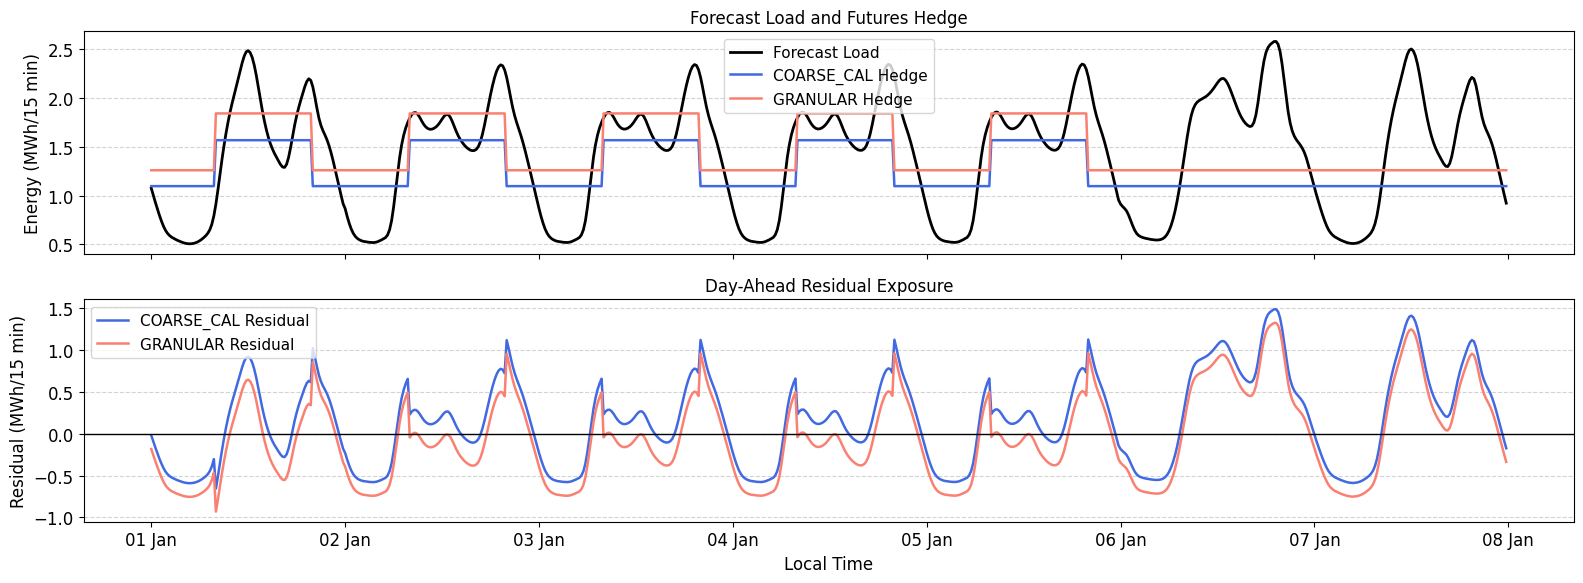

In [19]:
plot_start = pd.Timestamp('2024-01-01', tz='Europe/Berlin')
plot_end = plot_start + pd.Timedelta(days=7)
plot_data = cost_data[cost_data['timestamp_local'].ge(plot_start) & cost_data['timestamp_local'].lt(plot_end)]

fig, axes = plt.subplots(2, 1, figsize=(16, 6), sharex=True)
axes[0].plot(plot_data['timestamp_local'], plot_data['forecast_mwh'], color='black', linewidth=2, label='Forecast Load')
axes[0].plot(plot_data['timestamp_local'], plot_data['hedge_coarse_mwh'], color='royalblue', linewidth=1.8, label='COARSE_CAL Hedge')
axes[0].plot(plot_data['timestamp_local'], plot_data['hedge_granular_mwh'], color='salmon', linewidth=1.8, label='GRANULAR Hedge')
axes[0].set_ylabel('Energy (MWh/15 min)')
axes[0].set_title('Forecast Load and Futures Hedge')
axes[0].grid(axis='y', linestyle='--', color='lightgray', alpha=1)
axes[0].legend()
axes[1].plot(plot_data['timestamp_local'], plot_data['residual_coarse_cal_mwh'], color='royalblue', linewidth=1.8, label='COARSE_CAL Residual')
axes[1].plot(plot_data['timestamp_local'], plot_data['residual_granular_mwh'], color='salmon', linewidth=1.8, label='GRANULAR Residual')
axes[1].axhline(0, color='black', linewidth=1)
axes[1].set_xlabel('Local Time')
axes[1].set_ylabel('Residual (MWh/15 min)')
axes[1].set_title('Day-Ahead Residual Exposure')
axes[1].xaxis.set_major_locator(mdates.DayLocator(tz='Europe/Berlin'))
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%d %b', tz='Europe/Berlin'))
axes[1].grid(axis='y', linestyle='--', color='lightgray', alpha=1)
axes[1].legend()
plt.tight_layout()
plt.savefig(figures_dir / 'Stage 4 Forecast Hedge Residual.pdf', transparent=True)
plt.savefig(figures_dir / 'Stage 4 Forecast Hedge Residual.png', dpi=300, transparent=True)
plt.show()

## Imbalance settlement

$$I_t=A_t-L_t,\qquad C_{imb}=\sum_t I_tP_t^{imb},\qquad Premium_{imb}=\sum_t I_t(P_t^{imb}-P_t^{DA}).$$

Every strategy schedules the same forecast load, so all share the same imbalance settlement. Positive \(I_t\) is a short position; negative \(I_t\) is surplus volume. Signed reBAP determines whether settlement is a cost or credit.

In [20]:
cost_data['imbalance_mwh'] = cost_data['total_actual_mwh'] - cost_data['forecast_mwh']
cost_data['imbalance_settlement_eur'] = cost_data['imbalance_mwh'] * cost_data['imbalance_price_eur_mwh']
cost_data['imbalance_premium_eur'] = cost_data['imbalance_mwh'] * (cost_data['imbalance_price_eur_mwh'] - cost_data['day_ahead_price_eur_mwh'])

imbalance_settlement = cost_data['imbalance_settlement_eur'].sum()
imbalance_premium = cost_data['imbalance_premium_eur'].sum()
actual_da_cost = (cost_data['total_actual_mwh'] * cost_data['day_ahead_price_eur_mwh']).sum()
stage5_rows = []

for _, row in stage4_summary.iterrows():
    final_cost = row['Forecast Cost EUR'] + imbalance_settlement
    final_financial_cost = actual_da_cost - row['Futures Payoff EUR'] + imbalance_premium
    stage5_rows.append({'Strategy': row['Strategy'], 'Forecast Cost EUR': row['Forecast Cost EUR'], 'Imbalance Settlement EUR': imbalance_settlement, 'Imbalance Premium EUR': imbalance_premium, 'Final Cost EUR': final_cost, 'Final Financial Representation EUR': final_financial_cost, 'Reconciliation Error EUR': final_financial_cost - final_cost, 'Actual Annual MWh': cost_data['total_actual_mwh'].sum(), 'Average Procurement Price EUR/MWh': final_cost / cost_data['total_actual_mwh'].sum()})

stage5_summary = pd.DataFrame(stage5_rows)
unhedged_final_cost = stage5_summary.loc[stage5_summary['Strategy'].eq('UNHEDGED'), 'Final Cost EUR'].iloc[0]
stage5_summary['Saving vs UNHEDGED EUR'] = unhedged_final_cost - stage5_summary['Final Cost EUR']
assert stage5_summary['Reconciliation Error EUR'].abs().max() < 1e-6
assert stage5_summary['Imbalance Settlement EUR'].nunique() == 1
stage5_summary.to_csv(table_dir / '03_stage5_imbalance_summary.csv', index=False)
display(stage5_summary.round(4))

,Strategy,Forecast Cost EUR,Imbalance Settlement EUR,Imbalance Premium EUR,Final Cost EUR,Final Financial Representation EUR,Reconciliation Error EUR,Actual Annual MWh,Average Procurement Price EUR/MWh,Saving vs UNHEDGED EUR
0,UNHEDGED,3.506704e+06,30503.8398,13589.2439,3.537208e+06,3.537208e+06,0.0,43138.0,81.9975,0.0000
1,COARSE_CAL,3.450967e+06,30503.8398,13589.2439,3.481470e+06,3.481470e+06,-0.0,43138.0,80.7054,55737.3475
2,GRANULAR,3.451507e+06,30503.8398,13589.2439,3.482011e+06,3.482011e+06,-0.0,43138.0,80.7180,55196.6469


,Settlement Sign,Intervals,Net Imbalance MWh,Settlement EUR
0,"Long volume, negative reBAP: cost",3370,-81.4007,7668.8552
1,"Long volume, positive reBAP: credit",12545,-272.5825,-34729.7735
2,"Short volume, negative reBAP: credit",3592,85.0676,-5881.5917
3,"Short volume, positive reBAP: cost",15629,406.9156,63446.3498


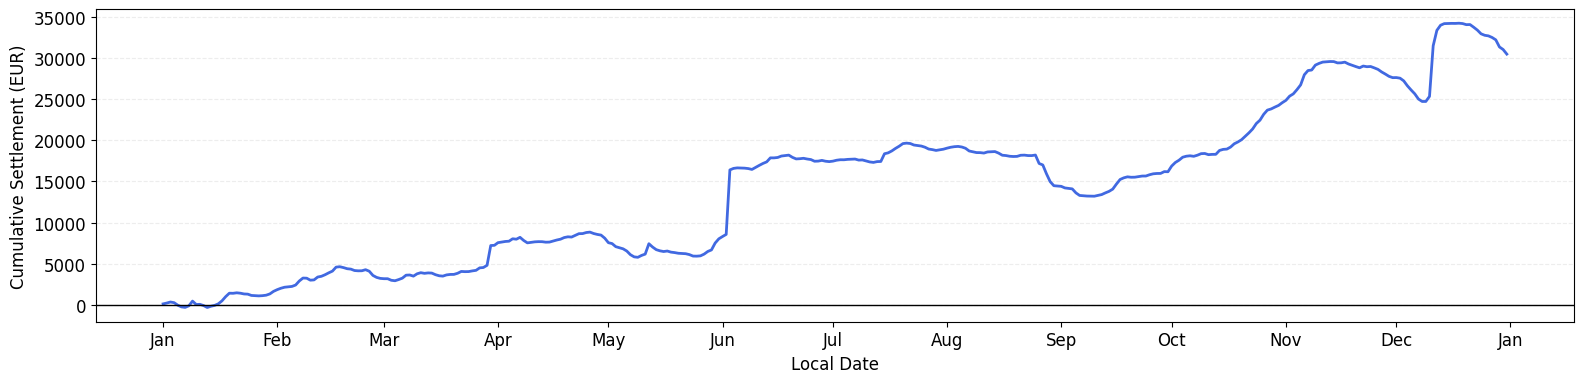

In [21]:
cost_data['Settlement Sign'] = np.select([(cost_data['imbalance_mwh'] > 0) & (cost_data['imbalance_price_eur_mwh'] >= 0), (cost_data['imbalance_mwh'] > 0) & (cost_data['imbalance_price_eur_mwh'] < 0), (cost_data['imbalance_mwh'] < 0) & (cost_data['imbalance_price_eur_mwh'] >= 0), (cost_data['imbalance_mwh'] < 0) & (cost_data['imbalance_price_eur_mwh'] < 0)], ['Short volume, positive reBAP: cost', 'Short volume, negative reBAP: credit', 'Long volume, positive reBAP: credit', 'Long volume, negative reBAP: cost'], default='Zero imbalance')
imbalance_sign_summary = cost_data.groupby('Settlement Sign', as_index=False).agg(Intervals=('imbalance_mwh', 'size'), **{'Net Imbalance MWh': ('imbalance_mwh', 'sum'), 'Settlement EUR': ('imbalance_settlement_eur', 'sum')})
imbalance_sign_summary.to_csv(table_dir / '03_imbalance_sign_summary.csv', index=False)
display(imbalance_sign_summary.round(4))

daily_imbalance = cost_data.set_index('timestamp_local').resample('D').agg(imbalance_mwh=('imbalance_mwh', 'sum'), imbalance_settlement_eur=('imbalance_settlement_eur', 'sum')).reset_index()
plt.figure(figsize=(16, 4))
plt.plot(daily_imbalance['timestamp_local'], daily_imbalance['imbalance_settlement_eur'].cumsum(), color='royalblue', linewidth=2)
plt.axhline(0, color='black', linewidth=1)
plt.xlabel('Local Date')
plt.ylabel('Cumulative Settlement (EUR)')
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(tz='Europe/Berlin'))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b', tz='Europe/Berlin'))
plt.grid(axis='y', linestyle='--', color='lightgray', alpha=0.4)
plt.tight_layout()
plt.savefig(figures_dir / 'Stage 5 Imbalance Settlement.pdf', transparent=True)
plt.savefig(figures_dir / 'Stage 5 Imbalance Settlement.png', dpi=300, transparent=True)
plt.show()

In [22]:
output_columns = ['timestamp_utc', 'timestamp_local', 'forecast_mwh', 'total_actual_mwh', 'is_peak', 'optimization_period', 'hpfc_eur_mwh', 'day_ahead_price_eur_mwh', 'imbalance_price_eur_mwh', 'hedge_unhedged_mwh', 'hedge_coarse_mwh', 'hedge_granular_mwh', 'residual_unhedged_mwh', 'residual_coarse_cal_mwh', 'residual_granular_mwh', 'futures_cost_unhedged_eur', 'futures_cost_coarse_eur', 'futures_cost_granular_eur', 'residual_da_cost_unhedged_eur', 'residual_da_cost_coarse_cal_eur', 'residual_da_cost_granular_eur', 'imbalance_mwh', 'imbalance_settlement_eur', 'imbalance_premium_eur']
cost_data[output_columns].to_csv(output_data_dir / '03_cost_timeseries.csv', index=False)

local_day_counts = cost_data.groupby(cost_data['timestamp_local'].dt.date).size()
output_files = ['Table/03_futures_positions.csv', 'Table/03_stage4_day_ahead_summary.csv', 'Table/03_stage5_imbalance_summary.csv', 'Table/03_imbalance_sign_summary.csv', 'Output Data/03_cost_timeseries.csv', 'Figures/Stage 4 Forecast Hedge Residual.pdf', 'Figures/Stage 4 Forecast Hedge Residual.png', 'Figures/Stage 5 Imbalance Settlement.pdf', 'Figures/Stage 5 Imbalance Settlement.png']
final_checks = pd.DataFrame([
    {'Check': 'Aligned quarter-hour rows', 'Observed': len(cost_data), 'Expected': expected_rows, 'Passed': len(cost_data) == expected_rows},
    {'Check': 'No missing analytical values', 'Observed': int(cost_data[output_columns].isna().sum().sum()), 'Expected': 0, 'Passed': cost_data[output_columns].isna().sum().sum() == 0},
    {'Check': 'Forecast portfolio reconciliation', 'Observed': cost_data['forecast_mwh'].sum(), 'Expected': 43000.0, 'Passed': np.isclose(cost_data['forecast_mwh'].sum(), 43000.0)},
    {'Check': 'DST-aware local day counts', 'Observed': sorted(local_day_counts.unique().tolist()), 'Expected': [92, 96, 100], 'Passed': set(local_day_counts.unique()) == {92, 96, 100}},
    {'Check': 'Non-negative futures positions', 'Observed': position_table['Position MW'].min(), 'Expected': '>= 0', 'Passed': position_table['Position MW'].ge(-1e-10).all()},
    {'Check': 'Stage 4 cost representations reconcile', 'Observed': stage4_summary['Reconciliation Error EUR'].abs().max(), 'Expected': '< 1e-6 EUR', 'Passed': stage4_summary['Reconciliation Error EUR'].abs().max() < 1e-6},
    {'Check': 'Stage 5 cost representations reconcile', 'Observed': stage5_summary['Reconciliation Error EUR'].abs().max(), 'Expected': '< 1e-6 EUR', 'Passed': stage5_summary['Reconciliation Error EUR'].abs().max() < 1e-6},
    {'Check': 'Imbalance settlement identical across strategies', 'Observed': stage5_summary['Imbalance Settlement EUR'].nunique(), 'Expected': 1, 'Passed': stage5_summary['Imbalance Settlement EUR'].nunique() == 1},
    {'Check': 'All Results outputs exist', 'Observed': sum((results_dir / name).exists() for name in output_files), 'Expected': len(output_files), 'Passed': all((results_dir / name).exists() for name in output_files)}
])
final_checks.to_csv(table_dir / '03_cost_accounting_checks.csv', index=False)
assert final_checks['Passed'].all()
display(final_checks)
print(f"{final_checks['Passed'].sum()} of {len(final_checks)} checks passed")

,Check,Observed,Expected,Passed
0,Aligned quarter-hour rows,35136,35136,True
1,No missing analytical values,0,0,True
2,Forecast portfolio reconciliation,43000.0,43000.0,True
3,DST-aware local day counts,"[92, 96, 100]","[92, 96, 100]",True
4,Non-negative futures positions,1.541214,>= 0,True
5,Stage 4 cost representations reconcile,0.0,< 1e-6 EUR,True
6,Stage 5 cost representations reconcile,0.0,< 1e-6 EUR,True
7,Imbalance settlement identical across strategies,1,1,True
8,All Results outputs exist,9,9,True


9 of 9 checks passed
